In [2]:
import pandas as pd
import geopandas as gpd
from collections import defaultdict
import time
import pandas as pd
import geopandas as gpd
from collections import defaultdict
import matplotlib.pyplot as plt
import geopandas as gpd

In [4]:
# Paths to your data
in_hucs = r"C:\Users\indumati\Box\Paper2\Geo Boundaries\HUC12s\WBD_National_GDB.gdb"
in_hucs_layer = 'WBDHU12'
in_hucs_keep_fields = ['huc12', 'areasqkm', 'tohuc', 'name']

service_areas_shapefile = r"C:/Users/indumati/Box/Paper2/Service Areas/ServiceAreasShapefile.shp"
tracts_shapefile = r"C:/Users/indumati/Box/Paper2/Geo Boundaries/CONUS Tracts/tracts_2021.shp"

# Read HUC12 data
print("Reading HUC12 data...")
huc_df = gpd.read_file(in_hucs, layer=in_hucs_layer)
huc_df = huc_df[in_hucs_keep_fields + ['geometry']]

# Read service areas and Census Tracts data
print("Reading Service Areas shapefile...")
service_areas_gdf = gpd.read_file(service_areas_shapefile)
print("Reading Census Tracts data...")
tracts_gdf = gpd.read_file(tracts_shapefile)

# Reproject datasets to Albers Equal Area projection for the US (EPSG:5070)
albers_crs = "EPSG:5070"
datasets = [huc_df, service_areas_gdf, tracts_gdf]
for i, gdf in enumerate(datasets):
    if gdf.crs != albers_crs:
        print(f"Reprojecting dataset {i + 1} to Albers CRS...")
        datasets[i] = gdf.to_crs(albers_crs)
huc_df, service_areas_gdf, tracts_gdf = datasets


Reading HUC12 data...
Reading Service Areas shapefile...
Reading Census Tracts data...
Reprojecting dataset 1 to Albers CRS...
Reprojecting dataset 2 to Albers CRS...
Reprojecting dataset 3 to Albers CRS...


In [5]:
# Build ToSeg mapping (HUC12 to its downstream HUC12)
ToSeg = dict(zip(huc_df['huc12'], huc_df['tohuc']))

# Function to find all downstream HUC12s
def findDown(FL, ToSeg):
    downs = []
    current = FL
    visited = set()
    while True:
        next_huc = ToSeg.get(current, None)
        if next_huc is None or next_huc == '' or next_huc in visited:
            break
        downs.append(next_huc)
        visited.add(next_huc)
        current = next_huc
    return downs


In [6]:
# Spatial join to find HUC12s in service areas
print("Performing spatial join to find HUC12s within service areas...")
hucs_in_service_areas = gpd.sjoin(huc_df, service_areas_gdf, how="inner", predicate="intersects")

# Build mapping of service area HUC12s
service_area_huc12s = hucs_in_service_areas['huc12'].unique()

# Spatial join between all HUC12s and tracts to find intersecting tracts
print("Performing spatial join between all HUC12s and Census Tracts...")
hucs_tracts_intersection = gpd.sjoin(huc_df[['huc12', 'geometry']], tracts_gdf[['GEOID', 'geometry']], how="inner", predicate="intersects")


Performing spatial join to find HUC12s within service areas...
Performing spatial join between all HUC12s and Census Tracts...


In [7]:
# Build mapping from HUC12 to tracts
huc12_to_tracts = defaultdict(set)
for idx, row in hucs_tracts_intersection.iterrows():
    huc12_code = row['huc12']
    tract_code = row['GEOID']
    huc12_to_tracts[huc12_code].add(tract_code)

# Process HUC12s within service areas to find their downstream tracts
print("Processing HUC12s in service areas to find downstream tracts...")
rows = []
for huc12 in service_area_huc12s:
    print(f"Processing HUC12: {huc12}")

    # Find downstream HUC12s
    downstream_hucs = findDown(huc12, ToSeg)
    downstream_hucs = [huc12] + downstream_hucs  # Include the current HUC12

    # Collect tracts intersecting downstream HUC12s
    downstream_tracts = set()
    for dhuc in downstream_hucs:
        tracts = huc12_to_tracts.get(dhuc, set())
        downstream_tracts.update(tracts)

    rows.append({
        'huc12': huc12,
        'downstream_tracts': list(downstream_tracts)
    })

# Create DataFrame from results
final_result_df = pd.DataFrame(rows)

# Save results to CSV
final_result_df.to_csv("service_area_huc12_to_downstream_tracts_2021.csv", index=False)

print("Processing complete. Results saved to 'service_area_huc12_to_downstream_tracts.csv'.")

Processing HUC12s in service areas to find downstream tracts...
Processing HUC12: 070200090402
Processing HUC12: 070200030503
Processing HUC12: 070200030602
Processing HUC12: 030701040701
Processing HUC12: 030701040506
Processing HUC12: 030701040603
Processing HUC12: 070200030701
Processing HUC12: 070300040804
Processing HUC12: 030701040702
Processing HUC12: 070200030702
Processing HUC12: 070200041102
Processing HUC12: 030701040804
Processing HUC12: 030701040805
Processing HUC12: 030701040806
Processing HUC12: 070200090401
Processing HUC12: 030901011102
Processing HUC12: 070200090403
Processing HUC12: 030901010902
Processing HUC12: 070300040601
Processing HUC12: 070300040602
Processing HUC12: 070200010901
Processing HUC12: 070200050503
Processing HUC12: 070200050605
Processing HUC12: 070200110508
Processing HUC12: 070200050604
Processing HUC12: 070900070103
Processing HUC12: 070300050401
Processing HUC12: 070900070402
Processing HUC12: 070700010403
Processing HUC12: 070700010201
Proces

In [13]:
import pandas as pd 

final_result_df = pd.read_csv('C:/Users/indumati/Box/Paper2/Python/service_area_huc12_to_downstream_tracts_2021.csv')
final_result_df.head()

,huc12,downstream_tracts
0,70200090402,"['47157003700', '17133600104', '17013951300', ..."
1,70200030503,"['47157003700', '17133600104', '17013951300', ..."
2,70200030602,"['47157003700', '17133600104', '17013951300', ..."
3,30701040701,"['13183970101', '13305970600', '13127000409', ..."
4,30701040506,"['13315960100', '13183970102', '13161960300', ..."


In [14]:
# Pad the huc12 column with leading zeros to ensure they are 12 characters long
final_result_df['huc12'] = final_result_df['huc12'].astype(str).str.zfill(12)

# Display the first few rows to verify
print(final_result_df.head())

          huc12                                  downstream_tracts
0  070200090402  ['47157003700', '17133600104', '17013951300', ...
1  070200030503  ['47157003700', '17133600104', '17013951300', ...
2  070200030602  ['47157003700', '17133600104', '17013951300', ...
3  030701040701  ['13183970101', '13305970600', '13127000409', ...
4  030701040506  ['13315960100', '13183970102', '13161960300', ...


Install `contextily` for basemap support.


C:\Users\indumati\AppData\Local\Temp\ipykernel_32616\2600848622.py:35: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\indumati\AppData\Local\Temp\ipykernel_32616\2600848622.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


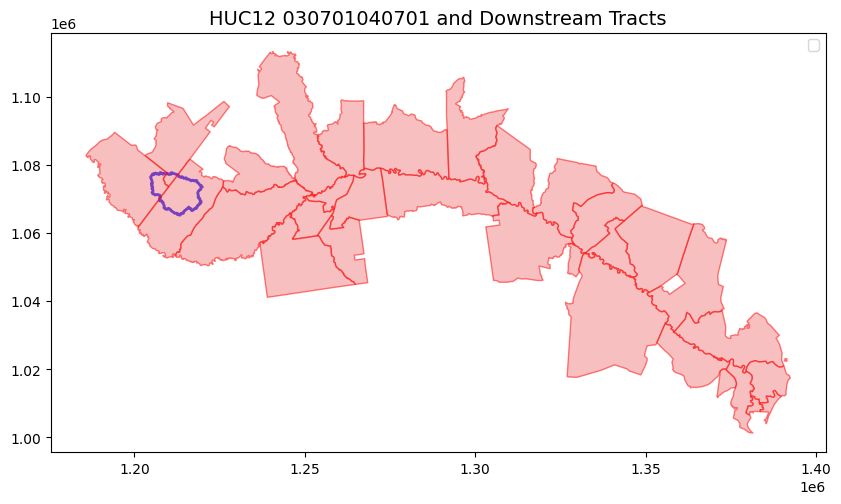

In [19]:
import matplotlib.pyplot as plt

# Specify the HUC12 code to plot (replace with your HUC12 code)
huc12_code_to_plot = "030701040701"  # Replace this with the actual HUC12 code

# Filter the target HUC12
selected_huc12 = huc_df[huc_df['huc12'] == huc12_code_to_plot]

# Get downstream tracts from the results DataFrame
import ast  # Import the ast module to safely evaluate a string representation of a list

# Get the downstream tracts as a list
downstream_tracts_list = final_result_df.loc[
    final_result_df['huc12'] == huc12_code_to_plot, 'downstream_tracts'
].values

if len(downstream_tracts_list) > 0:
    # Convert the serialized string to a list, if necessary
    downstream_tracts_list = ast.literal_eval(downstream_tracts_list[0])

    # Filter tracts GeoDataFrame for downstream tracts
    downstream_tracts = tracts_gdf[tracts_gdf['GEOID'].isin(downstream_tracts_list)]

    # Plot the HUC12 and downstream tracts
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot the HUC12 boundary
    selected_huc12.plot(ax=ax, edgecolor="blue", facecolor="none", linewidth=2, label="HUC12")

    # Plot the downstream tracts
    downstream_tracts.plot(ax=ax, edgecolor="red", facecolor="lightcoral", alpha=0.5, label="Downstream Tracts")

    # Add title and legend
    ax.set_title(f"HUC12 {huc12_code_to_plot} and Downstream Tracts", fontsize=14)
    ax.legend()

    # Add basemap for context (optional, requires `contextily`)
    try:
        import contextily as cx
        cx.add_basemap(ax, crs=tracts_gdf.crs.to_string())
    except ImportError:
        print("Install `contextily` for basemap support.")

    plt.show()
else:
    print(f"No downstream tracts found for HUC12 {huc12_code_to_plot}.")


In [16]:
test = final_result_df = pd.read_csv('C:/Users/indumati/Box/Paper2/All_SAs/allSAs_tract_upstreamhuc12_compiled.csv')


In [18]:
test.head()

,service_area,tract,upstream_huc12
0,Document/* ILF-KDFWR-Ed Mabry 2-Laurel Gorge ...,21089040502,50901030303
1,Document/* ILF-KDFWR-Ed Mabry 2-Laurel Gorge ...,21089040502,50901030304
2,Document/* ILF-KDFWR-Ed Mabry 2-Laurel Gorge ...,21089040502,50901030304
3,Document/* ILF-KDFWR-Ed Mabry 2-Laurel Gorge ...,21089040502,50901030302
4,Document/* ILF-KDFWR-Ed Mabry 2-Laurel Gorge ...,21089040502,50901030303


In [17]:
original_downstream_tracts = set(final_result_df.loc[final_result_df['huc12'] == huc12_code_to_plot, 'downstream_tracts'].explode())
second_code_downstream_tracts = set(test.loc[service_area_result_df['upstream_huc12'] == huc12_code_to_plot, 'tract'])

print("Original code downstream tracts:", original_downstream_tracts)
print("Second code downstream tracts:", second_code_downstream_tracts)
print("Difference:", second_code_downstream_tracts - original_downstream_tracts)

KeyError: 'huc12'